# Setup

In [1]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# import tpvalidator.workspace as workspace
# import tpvalidator.analysis.snn as snn
import hist
import mplhep as hep


from rich import print
from matplotlib.colors import LogNorm
from tpvalidator.analysis.histograms import cumsum_hist, cut_scan_to_df, compute_regaxis_specs

from tpvalidator.viz.tps import TrgPrimitivesPlotter
from tpvalidator.viz.backtracker import BackTrackerPlotter
from tpvalidator.viz.display import TriggerPrimitivesEventViewer
from tpvalidator.viz.term import dataframe_to_rich_table
from typing import Literal


# Data

In [3]:
import tpvalidator.datacatalogue as dctl

dataset_names = ['eminus', 'radbkg']
datasets = dctl.load('data/vd/1x8x14/3sig', dataset_names)
rad_ws=datasets['radbkg']
em_ws=datasets['eminus']


Workspace ar39 skipped

Workspace ar39_5e_00 skipped

Loading radbkg

Dataset 'radbkg': 10 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [
        [28, 'Rn222ChainFromPo218GenInUpperMesh1x8x14'],
        [27, 'Rn220ChainFromPb212GenInUpperMesh1x8x14'],
        [26, 'Kr85GenInLAr'],
        [25, 'Rn222ChainFromBi210GenInUpperMesh1x8x14'],
        [24, 'U238ChainGenInAnode'],
        [23, 'K40GenInCathode'],
        [22, 'K42From42ArGenInUpperMesh1x8x14'],
        [21, 'Th232ChainGenInCathode'],
        [20, 'CavernNGammasAtLAr1x8x14'],
        [19, 'Rn222ChainRn222GenInLAr'],
        [18, 'U238ChainGenInCathode'],
        [17, 'K40GenInAnode'],
        [16, 'Rn220ChainPb212GenInLAr'],
        [15, 'foamGammasAtLAr1x8x14'],
        [14, 'Rn222ChainFromPb214GenInUpperMesh1x8x14'],
        [13, 'K42From42ArGenInLAr'],
        [12, 'Rn222ChainGenInPDS'],
        [11, 'Ar42GenInLAr'],
        [10, 'CavernwallGammasAtLAr1x8x14'],
        [9, 'Rn222ChainPb210GenInLAr'],
        [8, 'Ar39GenInLAr'],
        [7, 'Rn222ChainPb214GenInLAr'],
        [6, 'Rn222ChainFromPb210GenInUpperMesh1x8x14'],
        [5, 'Rn222ChainPo218GenInLAr'],
        [4, 'CavernwallNeutronsAtLAr1x8x14'],
        [3, 'Rn222ChainFromBi214GenInUpperMesh1x8x14'],
        [2, 'CryostatNGammasAtLAr1x8x14'],
        [1, 'Th232ChainGenInAnode'],
        [0, 'Rn222ChainBi214GenInLAr']
    ],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 27,
            'threshold_tpg_plane1': 27,
            'threshold_tpg_plane2': 27,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Loading eminus

Dataset 'eminus': 1000 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [[0, 'generator']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 27,
            'threshold_tpg_plane1': 27,
            'threshold_tpg_plane2': 27,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

# Devel

In [4]:
def expand_to_dataframe(h, cat_axis_name, cut_axis_name):
    cat = h.axes[cat_axis_name]

    cuts = h.axes[cut_axis_name].edges

    data = {f'{cut_axis_name}_min': cuts}

    for k in cat:

        # h_s = h[k, 1j, slice(None)]
        # h_n = h[k, 0j, slice(None)]
        h_t = h[k, sum, slice(None)]

        h_cs_t = cumsum_hist(h_t, direction='right', flow=True)
        # h_cs_s = cumsum_hist(h_s, direction='right', flow=True)
        # h_cs_n = cumsum_hist(h_n, direction='right', flow=True)

        data[f'{cat_axis_name}_{k}'] = h_cs_t.values(flow=True)
        # data[f'{cat_axis_name}_{k}_s'] = h_cs_s.values()
        # data[f'{cat_axis_name}_{k}_n'] = h_cs_n.values()

    for k,v in data.items():
        print(k, len(v))
    return pd.DataFrame(data)

# Trigger Primitive Rates vs `adc_peak`

In [5]:
tpp = TrgPrimitivesPlotter(rad_ws)



In [6]:
h_cs = tpp.make_cutsequence_hist('adc_peak', list(range(28,60,2)))


                                    Rate per CRP                                    
┏━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃    ┃ adc_peak_min ┃ readout_plane_id_0 ┃ readout_plane_id_1 ┃ readout_plane_id_2 ┃
┡━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ 0  │ 28.0         │ 1848587.39 Hz      │ 1836888.24 Hz      │ 1958559.66 Hz      │
│ 1  │ 30.0         │ 1000059.66 Hz      │ 981062.18 Hz       │ 1014973.11 Hz      │
│ 2  │ 32.0         │ 552958.82 Hz       │ 529071.43 Hz       │ 544288.24 Hz       │
│ 3  │ 34.0         │ 322497.48 Hz       │ 296134.45 Hz       │ 319451.26 Hz       │
│ 4  │ 36.0         │ 206827.73 Hz       │ 179746.22 Hz       │ 215671.43 Hz       │
│ 5  │ 38.0         │ 149448.74 Hz       │ 122152.94 Hz       │ 166618.49 Hz       │
│ 6  │ 40.0         │ 120132.77 Hz       │ 93168.07 Hz        │ 141922.69 Hz       │
│ 7  │ 42.0         │ 104367.23 Hz       │ 77392.44 Hz        │ 128520.17 Hz       │
│ 8  │ 44.0         │ 94331.93 Hz        │ 67691.60 Hz        │ 119898.32 Hz       │
│ 9  │ 46.0         │ 87382.35 Hz        │ 61283.19 Hz        │ 113202.52 Hz       │
│ 10 │ 48.0         │ 81863.03 Hz        │ 56449.58 Hz        │ 107460.50 Hz       │
│ 11 │ 50.0         │ 77153.78 Hz        │ 52306.72 Hz        │ 102178.15 Hz       │
│ 12 │ 52.0         │ 72857.14 Hz        │ 48834.45 Hz        │ 97544.54 Hz        │
│ 13 │ 54.0         │ 68991.60 Hz        │ 45636.97 Hz        │ 93130.25 Hz        │
│ 14 │ 56.0         │ 65455.46 Hz        │ 42762.18 Hz        │ 89043.70 Hz        │
│ 15 │ 58.0         │ 62156.30 Hz        │ 40160.50 Hz        │ 85232.77 Hz        │
└────┴──────────────┴────────────────────┴────────────────────┴────────────────────┘

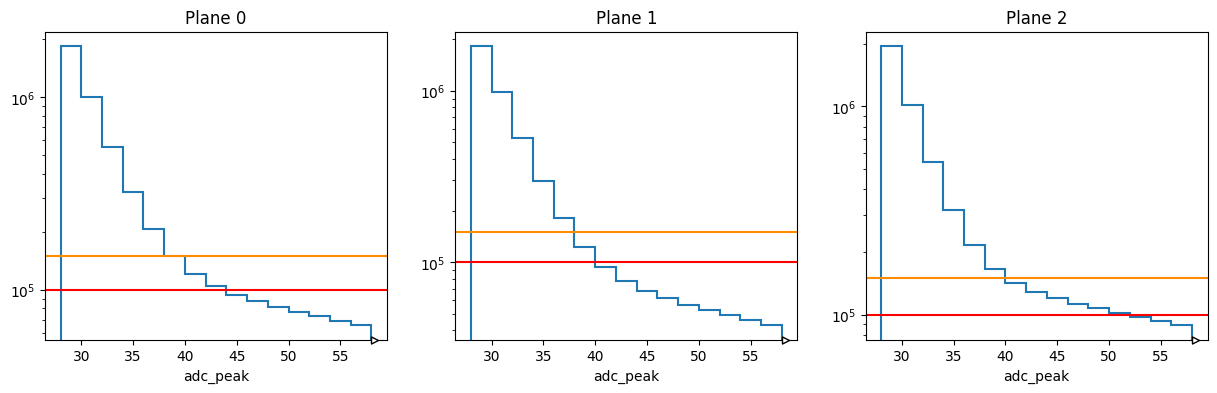

In [7]:
# h_cs = cumsum_hist_nd(h, 'adc_peak', direction='right', flow=True)

h_cs_tot = h_cs[:, sum, :]
h_cs_sig = h_cs[:, 1j, :]
h_cs_noi = h_cs[:, 0j, :]

def col_crp_rate(r):

    if r > 1.5e5:
        col = 'red'
    elif r < 1e5:
        col = 'green'
    else:
        col = 'yellow'

    r_str = f'{r:.2f} Hz'
    if col:
        r_str = f'[{col}]{r_str}[/{col}]'
    return r_str
        
    

fmts={
    f"readout_plane_id_{rop}":'{:.2f} Hz' for rop in range(3)
}
fmts={
    f"readout_plane_id_{rop}": col_crp_rate for rop in range(3)
}

h_rate_crp = h_cs_tot/tpp.simulated_time()/28

rate_tot = dataframe_to_rich_table(
    cut_scan_to_df(h_rate_crp, 'readout_plane_id', 'adc_peak'),
    formatters=fmts)
rate_tot.title = "Rate per CRP"
print(rate_tot)




fig, axes = plt.subplots(1,3, figsize=(15,4))

for rop_id in range(3):
    _ax=axes[rop_id]
    hep.histplot(h_rate_crp[rop_id,:], ax=_ax)

    _ax.set_yscale('log')
    _ax.set_title(f"Plane {rop_id}")
    _ax.axhline(1.5e5, c='darkorange')
    _ax.axhline(1e5, c='red')

# Signal completeness vs threshold

In [38]:
btp = BackTrackerPlotter(em_ws)
evw = TriggerPrimitivesEventViewer(em_ws)

In [ ]:
eff_base = btp.compute_nel_eff_by_plane()
ke = em_ws.mctruths[['event_uid', 'kinetic_energy']]


eff_base_m = eff_base.mean()


rows = []


for i in range(26,61,2):
    eff_cut = btp.compute_nel_eff_by_plane(f"adc_peak > {i}")

    m = (eff_cut.mean()/eff_base_m)

    rows.append(m)
#     print(dict(m))


pd.DataFrame(rows)


,nel_eff_rop0,nel_eff_rop1,nel_eff_rop2
0,1.000000,1.000000,1.000000
1,0.999539,0.999415,0.999642
2,0.997105,0.998255,0.998861
3,0.995920,0.997306,0.998188
4,0.994654,0.996254,0.997224
5,0.993568,0.995140,0.996092
6,0.992508,0.993906,0.995247
7,0.991268,0.992522,0.994358
8,0.990161,0.991284,0.993405
9,0.988728,0.989841,0.992278


In [132]:
eff_0.mean().index

Index(['nel_eff_rop0', 'nel_eff_rop1', 'nel_eff_rop2'], dtype='str')

In [112]:
np.arange(0,1.01,0.02)

array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
       0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
       0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
       0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
       0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ])

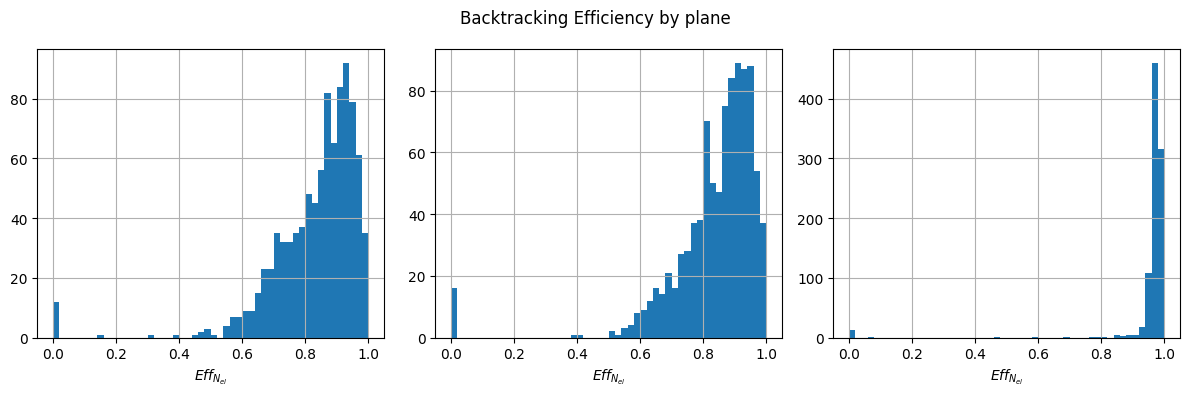

In [114]:
fig = btp.draw_nel_eff_by_plane(tp_query="adc_peak > 0", bins=np.arange(0,1.01,0.02))

<Axes: xlabel='kinetic_energy', ylabel='nel_eff_rop1'>

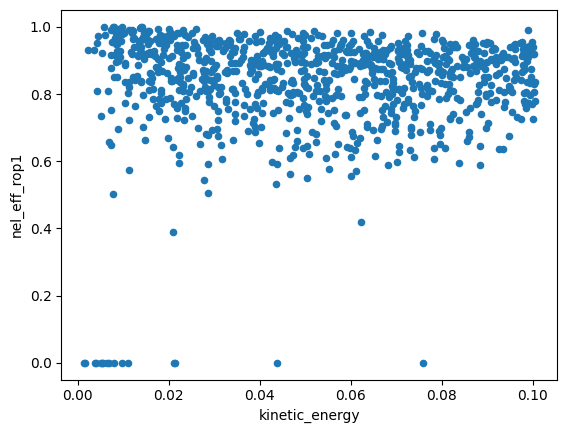

In [81]:
eff_ke.plot.scatter(x='kinetic_energy', y='nel_eff_rop1')

In [12]:

tpp = TrgPrimitivesPlotter(rad_ws)

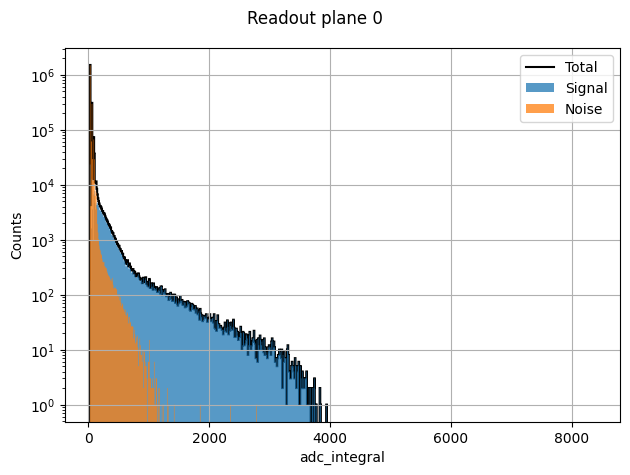

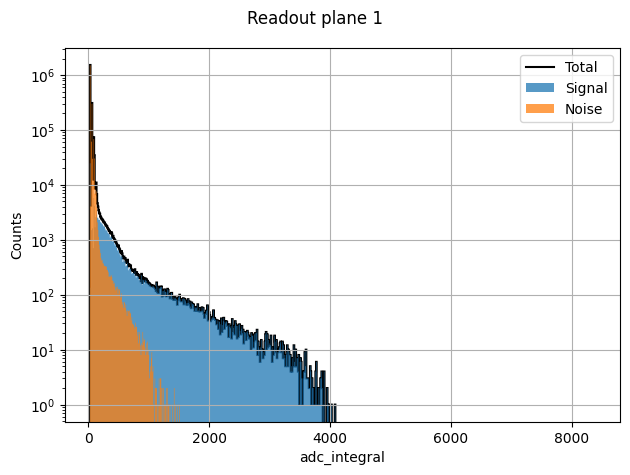

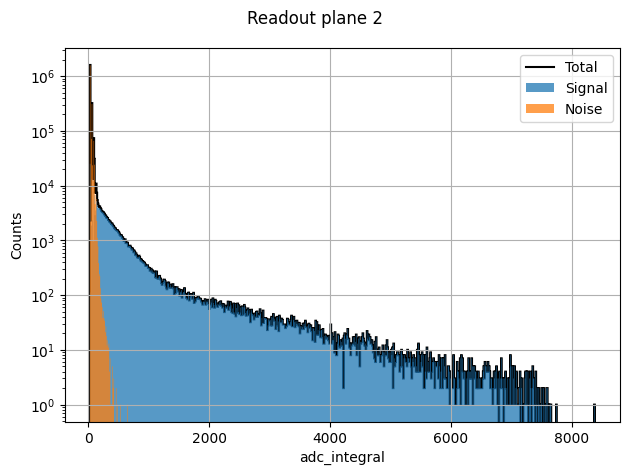

In [13]:
h = tpp.make_var_reghist('adc_integral', 10)

for rop_id in range(3):

    fig, ax = plt.subplots()
    hep.histplot(h[rop_id,sum,:], ax=ax, yerr=False, color='black', label='Total')
    hep.histplot(h[rop_id,1,:], ax=ax, yerr=False, histtype='fill', label='Signal', alpha=0.75)
    hep.histplot(h[rop_id,0,:], ax=ax, yerr=False, histtype='fill', label='Noise', alpha=0.75)
    ax.set_yscale('log')
    ax.grid()
    ax.legend()
    ax.set_ylabel('Counts')
    
    fig.suptitle(f"Readout plane {rop_id}")

    fig.tight_layout()

In [14]:

rop_axis = tpp._make_intcat_axis('readout_plane_id', label='Readout Plane')
bt_sig_axis = tpp._make_intcat_axis('bt_is_signal', label='Noise/Signal')
adc_peak_axis = hist.axis.Regular( *compute_regaxis_specs(tpp._df['adc_peak'], 2), name='adc_peak')
sot_axis = hist.axis.Regular( *compute_regaxis_specs(tpp._df['samples_over_threshold'], 1), name='samples_over_threshold')


h_spec = [rop_axis, bt_sig_axis, adc_peak_axis, sot_axis]
h = tpp._build_histogram(h_spec)

AttributeError: 'TrgPrimitivesPlotter' object has no attribute '_make_intcat_axis'

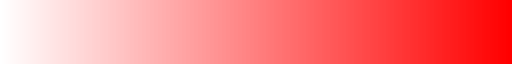

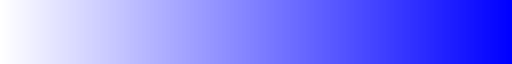

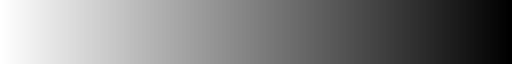

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

cmap_trans_red = LinearSegmentedColormap.from_list(
    'trans_red',
    [(1, 0, 0, 0), (1, 0, 0, 1)]   # transparent red → solid red
)

cmap_trans_blue = LinearSegmentedColormap.from_list(
    'trans_red',
    [(0, 0, 1, 0), (0, 0, 1, 1)]   # transparent red → solid red
)

cmap_trans_black = LinearSegmentedColormap.from_list(
    'trans_red',
    [(0, 0, 0, 0), (0, 0, 0, 1)]   # transparent red → solid red
)

display(cmap_trans_red)
display(cmap_trans_blue)
display(cmap_trans_black)

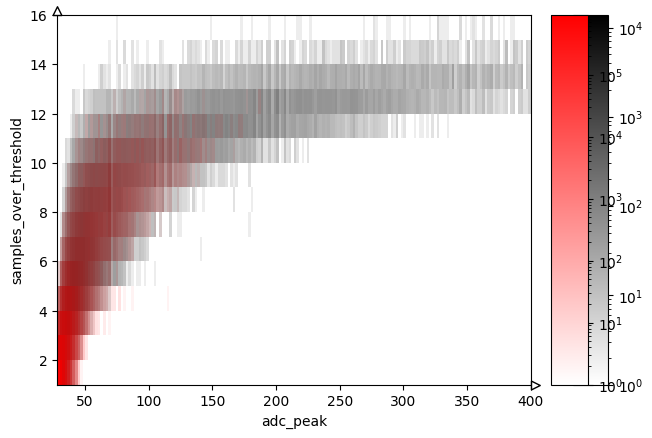

In [ ]:
from matplotlib.colors import LogNorm

fix, axes = plt.subplots(1,1)

rop_id = 1
hep.hist2dplot(h[rop_id,1,:400j,:16j], cmap=cmap_trans_black, ax=axes, norm=LogNorm())
hep.hist2dplot(h[rop_id,0,:400j,:16j], cmap=cmap_trans_red, ax=axes, norm=LogNorm())

fig.tight_layout()

# Don't Run Me

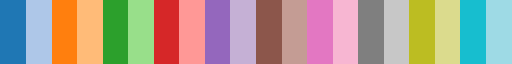

In [ ]:
plt.colormaps['tab20']

In [ ]:

rop_axis = tpp._make_intcat_axis('readout_plane_id', label='Readout Plane')
bt_sig_axis = tpp._make_intcat_axis('bt_is_signal', label='Noise/Signal')

# Create the binning 
min_adc_peak =32
max_adc_peak = 62
n_bins = (max_adc_peak-min_adc_peak)//2
adc_peak_axis = hist.axis.Regular(n_bins, min_adc_peak, max_adc_peak, name='adc_peak')

h_spec = [rop_axis, bt_sig_axis, adc_peak_axis]

# make the count primitive
h = tpp._build_histogram(h_spec)

display(h)



Hist(
  IntCategory([0, 1, 2], name='readout_plane_id', label='Readout Plane'),
  IntCategory([0, 1], name='bt_is_signal', label='Noise/Signal'),
  Regular(15, 32, 62, name='adc_peak'),
  storage=Double()) # Sum: 1732475.0 (6716402.0 with flow)

In [ ]:
cat = h.axes['readout_plane_id']

,adc_peak_min,readout_plane_id_0_t,readout_plane_id_0_s,readout_plane_id_0_n,readout_plane_id_1_t,readout_plane_id_1_s,readout_plane_id_1_n,readout_plane_id_2_t,readout_plane_id_2_s,readout_plane_id_2_n
0,32.0,552958.823529,123645.378151,429313.445378,529071.428571,90970.588235,438100.840336,544288.235294,164917.647059,379370.588235
1,34.0,322497.478992,114697.478992,207800.000000,296134.453782,82732.773109,213401.680672,319451.260504,154794.117647,164657.142857
2,36.0,206827.731092,106810.924370,100016.806723,179746.218487,75874.789916,103871.428571,215671.428571,145791.596639,69879.831933
3,38.0,149448.739496,99888.235294,49560.504202,122152.941176,69789.075630,52363.865546,166618.487395,137599.159664,29019.327731
4,40.0,120132.773109,93440.336134,26692.436975,93168.067227,64536.134454,28631.932773,141922.689076,130067.226891,11855.462185
5,42.0,104367.226891,87769.747899,16597.478992,77392.436975,59916.806723,17475.630252,128520.168067,123271.428571,5248.739496
6,44.0,94331.932773,82499.159664,11832.773109,67691.596639,55644.537815,12047.058824,119898.319328,116997.478992,2900.840336
7,46.0,87382.352941,77754.621849,9627.731092,61283.193277,51874.789916,9408.403361,113202.521008,111171.428571,2031.092437
8,48.0,81863.025210,73514.285714,8348.739496,56449.579832,48515.126050,7934.453782,107460.504202,105896.638655,1563.865546
9,50.0,77153.781513,69638.655462,7515.126050,52306.722689,45357.142857,6949.579832,102178.151261,100897.478992,1280.672269


                                   Readout Plane 0                                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ adc_peak_min ┃ readout_plane_id_0_t ┃ readout_plane_id_0_s ┃ readout_plane_id_0_n ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ 32           │ 552958.8             │ 123645.4             │ 429313.4             │
│ 34           │ 322497.5             │ 114697.5             │ 207800.0             │
│ 36           │ 206827.7             │ 106810.9             │ 100016.8             │
│ 38           │ 149448.7             │ 99888.2              │ 49560.5              │
│ 40           │ 120132.8             │ 93440.3              │ 26692.4              │
│ 42           │ 104367.2             │ 87769.7              │ 16597.5              │
│ 44           │ 94331.9              │ 82499.2              │ 11832.8              │
│ 46           │ 87382.4              │ 77754.6              │ 9627.7               │
│ 48           │ 81863.0              │ 73514.3              │ 8348.7               │
│ 50           │ 77153.8              │ 69638.7              │ 7515.1               │
│ 52           │ 72857.1              │ 66022.7              │ 6834.5               │
│ 54           │ 68991.6              │ 62707.6              │ 6284.0               │
│ 56           │ 65455.5              │ 59684.0              │ 5771.4               │
│ 58           │ 62156.3              │ 56843.7              │ 5312.6               │
│ 60           │ 59108.4              │ 54174.8              │ 4933.6               │
└──────────────┴──────────────────────┴──────────────────────┴──────────────────────┘

                                   Readout Plane 1                                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ adc_peak_min ┃ readout_plane_id_1_t ┃ readout_plane_id_1_s ┃ readout_plane_id_1_n ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ 32           │ 529071.4             │ 90970.6              │ 438100.8             │
│ 34           │ 296134.5             │ 82732.8              │ 213401.7             │
│ 36           │ 179746.2             │ 75874.8              │ 103871.4             │
│ 38           │ 122152.9             │ 69789.1              │ 52363.9              │
│ 40           │ 93168.1              │ 64536.1              │ 28631.9              │
│ 42           │ 77392.4              │ 59916.8              │ 17475.6              │
│ 44           │ 67691.6              │ 55644.5              │ 12047.1              │
│ 46           │ 61283.2              │ 51874.8              │ 9408.4               │
│ 48           │ 56449.6              │ 48515.1              │ 7934.5               │
│ 50           │ 52306.7              │ 45357.1              │ 6949.6               │
│ 52           │ 48834.5              │ 42633.6              │ 6200.8               │
│ 54           │ 45637.0              │ 40079.0              │ 5558.0               │
│ 56           │ 42762.2              │ 37760.5              │ 5001.7               │
│ 58           │ 40160.5              │ 35647.9              │ 4512.6               │
│ 60           │ 37843.7              │ 33744.5              │ 4099.2               │
└──────────────┴──────────────────────┴──────────────────────┴──────────────────────┘

                                   Readout Plane 2                                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ adc_peak_min ┃ readout_plane_id_2_t ┃ readout_plane_id_2_s ┃ readout_plane_id_2_n ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ 32           │ 544288.2             │ 164917.6             │ 379370.6             │
│ 34           │ 319451.3             │ 154794.1             │ 164657.1             │
│ 36           │ 215671.4             │ 145791.6             │ 69879.8              │
│ 38           │ 166618.5             │ 137599.2             │ 29019.3              │
│ 40           │ 141922.7             │ 130067.2             │ 11855.5              │
│ 42           │ 128520.2             │ 123271.4             │ 5248.7               │
│ 44           │ 119898.3             │ 116997.5             │ 2900.8               │
│ 46           │ 113202.5             │ 111171.4             │ 2031.1               │
│ 48           │ 107460.5             │ 105896.6             │ 1563.9               │
│ 50           │ 102178.2             │ 100897.5             │ 1280.7               │
│ 52           │ 97544.5              │ 96421.0              │ 1123.5               │
│ 54           │ 93130.3              │ 92153.8              │ 976.5                │
│ 56           │ 89043.7              │ 88202.5              │ 841.2                │
│ 58           │ 85232.8              │ 84487.4              │ 745.4                │
│ 60           │ 81711.8              │ 81058.8              │ 652.9                │
└──────────────┴──────────────────────┴──────────────────────┴──────────────────────┘

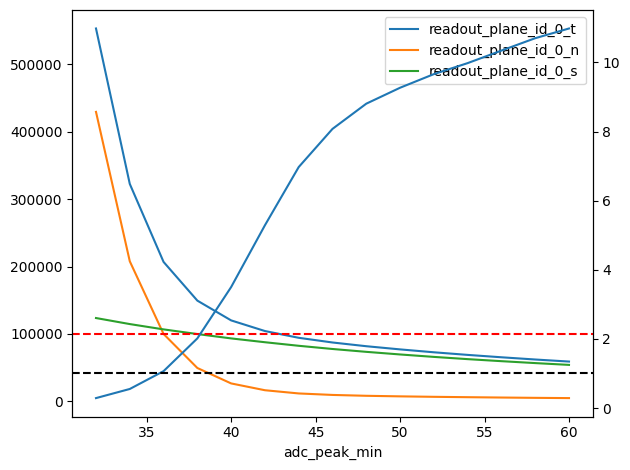

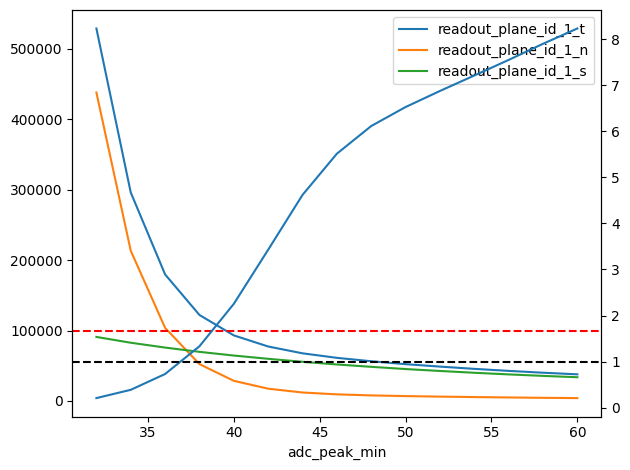

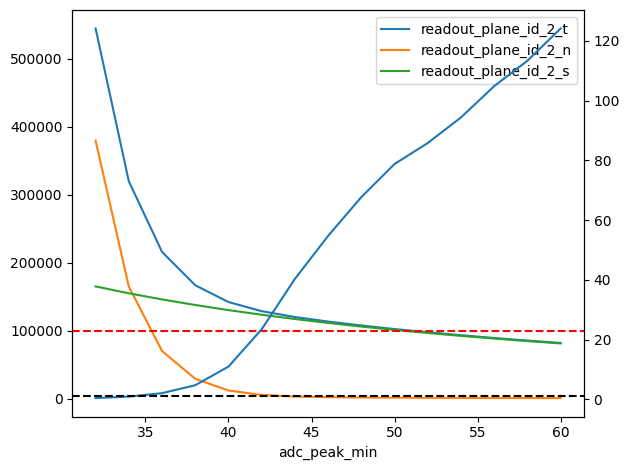

In [ ]:
def expand_to_dataframe(h, cat_axis_name, cut_axis_name):
    cat = h.axes[cat_axis_name]

    cuts = h.axes[cut_axis_name].edges[:-1]

    data = {f'{cut_axis_name}_min': cuts}

    for k in cat:

        h_s = h[k, 1j, slice(None)]
        h_n = h[k, 0j, slice(None)]
        h_t = h[k, sum, slice(None)]

        h_cs_t = cumsum_hist(h_t, direction='right', flow=True)
        h_cs_s = cumsum_hist(h_s, direction='right', flow=True)
        h_cs_n = cumsum_hist(h_n, direction='right', flow=True)

        data[f'{cat_axis_name}_{k}_t'] = h_cs_t.values()
        data[f'{cat_axis_name}_{k}_s'] = h_cs_s.values()
        data[f'{cat_axis_name}_{k}_n'] = h_cs_n.values()

    return pd.DataFrame(data)

rates_per_crp = expand_to_dataframe(h/tpp.simulated_time()/28, 'readout_plane_id', 'adc_peak')
display(rates_per_crp)

from tpvalidator.viz.term import dataframe_to_rich_table

print(dataframe_to_rich_table(
    rates_per_crp[[
        'adc_peak_min',
        'readout_plane_id_0_t',
        'readout_plane_id_0_s',
        'readout_plane_id_0_n'
        ]], 
    show_index=False, 
    title='Readout Plane 0',
    formatters={
        'adc_peak_min': '{:.0f}',
        'readout_plane_id_0_t': '{:.1f}',
        'readout_plane_id_0_s': '{:.1f}',
        'readout_plane_id_0_n': '{:.1f}' 
        }
    ))


print(dataframe_to_rich_table(
    rates_per_crp[[
        'adc_peak_min',
        'readout_plane_id_1_t',
        'readout_plane_id_1_s',
        'readout_plane_id_1_n'
        ]], 
    show_index=False, 
    title='Readout Plane 1',
    formatters={
        'adc_peak_min': '{:.0f}',
        'readout_plane_id_1_t': '{:.1f}',
        'readout_plane_id_1_s': '{:.1f}',
        'readout_plane_id_1_n': '{:.1f}' 
        }
    ))

print(dataframe_to_rich_table(
    rates_per_crp[[
        'adc_peak_min',
        'readout_plane_id_2_t',
        'readout_plane_id_2_s',
        'readout_plane_id_2_n'
        ]], 
    show_index=False, 
    title='Readout Plane 2',
    formatters={
        'adc_peak_min': '{:.0f}',
        'readout_plane_id_2_t': '{:.1f}',
        'readout_plane_id_2_s': '{:.1f}',
        'readout_plane_id_2_n': '{:.1f}' 
        }
    ))

for rop in range(3):
    fig, ax = plt.subplots()

    rates_per_crp.plot(x='adc_peak_min', y=f'readout_plane_id_{rop}_t', ax=ax)
    rates_per_crp.plot(x='adc_peak_min', y=f'readout_plane_id_{rop}_n', ax=ax)
    rates_per_crp.plot(x='adc_peak_min', y=f'readout_plane_id_{rop}_s', ax=ax)
    ax.axhline(1e5, color='red', linestyle='--')


    ax_2 = ax.twinx()
    ax_2.plot(rates_per_crp['adc_peak_min'], rates_per_crp[f'readout_plane_id_{rop}_s']/rates_per_crp[f'readout_plane_id_{rop}_n'])
    ax_2.axhline(1, color='black', linestyle='--')

    fig.tight_layout()

In [ ]:
import hist

def make_int_axis(df, col_name:str, **kwargs):

    if df[col_name].dtype.kind not in ("i", "u"):
        raise TypeError(f"Column {col_name} is not of type integer")

    values = df[col_name].values
    lo, hi = np.min(values), np.max(values)
    return hist.axis.Integer(lo, hi+1, name=col_name, **kwargs)

def make_intcat_axis(df, col_name:str, **kwargs):

    if df[col_name].dtype.kind not in ("i", "u"):
        raise TypeError(f"Column {col_name} is not of type integer")

    return hist.axis.IntCategory(df[col_name].unique(), name=col_name, **kwargs)

_df=rad_ws.tps

rop_axis = make_intcat_axis(_df, 'readout_plane_id', label='Readout Plane')
bt_sig_axis = make_intcat_axis(_df, 'bt_is_signal', label='Noise/Signal')


# wrap in a function or?
min_adc_peak = 27
max_adc_peak = 62
n_bins = 7
adc_peak_axis = hist.axis.Regular(n_bins, min_adc_peak, max_adc_peak, name='adc_peak')




Hist(
  IntCategory([0, 1, 2], name='readout_plane_id', label='Readout Plane'),
  IntCategory([1, 0], name='bt_is_signal', label='Noise/Signal'),
  Regular(7, 27, 62, name='adc_peak'),
  storage=Double()) # Sum: 6513558.0 (6716402.0 with flow)

Hist(Regular(7, 27, 62, name='adc_peak'), storage=Double()) # Sum: 98503.0 (136586.0 with flow)

[    0. 28331. 21690. 15264. 11580.  8987.  7117.  5534. 38083.]

[0.000000e+00 1.527971e+06 4.340310e+05 6.651300e+04 1.064500e+04
 2.772000e+03 1.740000e+03 1.174000e+03 4.465000e+03]

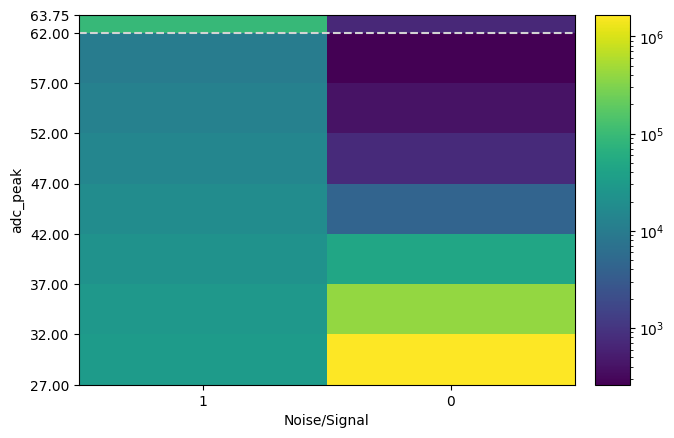

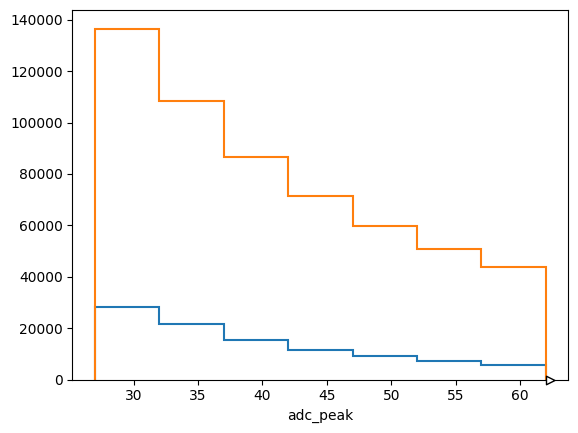

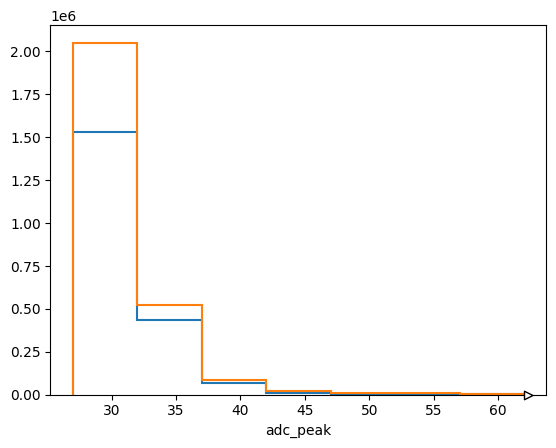

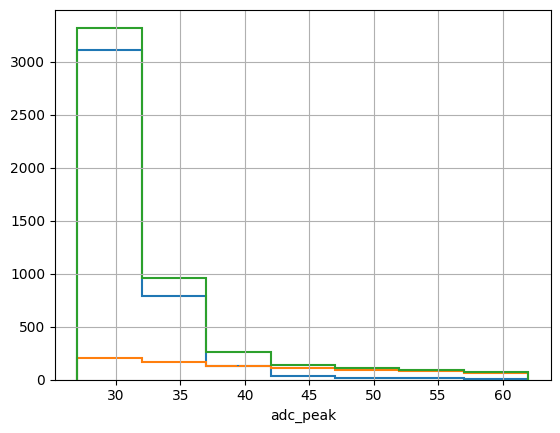

In [ ]:
h_spec = [rop_axis, adc_peak_axis]
h_spec = [rop_axis, bt_sig_axis]
h_spec = [rop_axis, bt_sig_axis, adc_peak_axis]


h = hist.Hist(*h_spec)

kwa = {
    a.name: _df[a.name]
    for a in h_spec
}
h.fill(**kwa)



# kwa={
#     'readout_plane_id': _df['readout_plane_id'],
#     'adc_peak': _df['adc_peak'],
# }
fig, ax = plt.subplots()

artists = hep.hist2dplot(h[2, :, :], flow='show', norm=LogNorm(), ax=ax)

display(h)

from tpvalidator.analysis.histograms import cumsum_hist

rop_id = 1
h_coll_sig = h[rop_id,1j, :]
h_coll_noi = h[rop_id,0j, :]
display(h_coll_sig)


fig, ax = plt.subplots()
print(h_coll_sig.values(flow=True))
hep.histplot(h_coll_sig, ax=ax)

h_coll_sig_cum = cumsum_hist(h_coll_sig, direction='right', flow=True)
hep.histplot(h_coll_sig_cum, ax=ax)

fig, ax = plt.subplots()
print(h_coll_noi.values(flow=True))
hep.histplot(h_coll_noi, ax=ax)

h_coll_noi_cum = cumsum_hist(h_coll_noi, direction='right', flow=True)
hep.histplot(h_coll_noi_cum, ax=ax)

sim_t = tpp.simulated_time()

num_crp = 28

h_coll_all_sum = h_coll_sig_cum+h_coll_noi_cum

h_rate_crp_col_noi = h_coll_noi_cum*sim_t/num_crp
h_rate_crp_col_sig = h_coll_sig_cum*sim_t/num_crp
h_rate_crt_col_all = h_coll_all_sum*sim_t/num_crp

fig, ax = plt.subplots()
hep.histplot(h_rate_crp_col_noi, ax=ax)
hep.histplot(h_rate_crp_col_sig, ax=ax)
hep.histplot(h_rate_crt_col_all, ax=ax)
ax.grid(True)



# print(h[2,:].values(flow=True))
# print(sum(h[2,:].values(flow=True)))

In [ ]:
from rich.table import Table

_t = Table('adc_peak cut', 'rate/CRP [Hz]', 'counts (all)', 'counts (sig)', 'counts (noise)')

for i, e in enumerate(h_rate_crt_col_all.axes[0].edges[:-1]):
    _bin_val = h_rate_crt_col_all[i]
    _bin_count_val = h_coll_all_sum[i]
    _bin_count_val_sig = h_coll_sig_cum[i]
    _bin_count_val_noi = h_coll_noi_cum[i]
    print(i, e, _bin_val.value, _bin_val.variance)
    _t.add_row(f">= {int(e):d}", f"{_bin_val.value:.2f}", f"{int(_bin_count_val.value)}", f"{int(_bin_count_val_sig.value)}",f"{int(_bin_count_val_noi.value)}")

print(_t)

0 27.0 3317.879375 5.036066908482142

1 32.0 955.6352678571428 1.450517817283163

2 37.0 263.91589285714286 0.4005866230867346

3 42.0 139.79008928571426 0.21218138552295918

4 46.99999999999999 106.05571428571429 0.16097742346938773

5 52.0 88.20723214285714 0.13388597735969385

6 57.0 74.76357142857141 0.11348042091836733

┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ adc_peak cut ┃ rate/CRP [Hz] ┃ counts (all) ┃ counts (sig) ┃ counts (noise) ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ >= 27        │ 3317.88       │ 2185897      │ 136586       │ 2049311        │
│ >= 32        │ 955.64        │ 629595       │ 108255       │ 521340         │
│ >= 37        │ 263.92        │ 173874       │ 86565        │ 87309          │
│ >= 42        │ 139.79        │ 92097        │ 71301        │ 20796          │
│ >= 46        │ 106.06        │ 69872        │ 59721        │ 10151          │
│ >= 52        │ 88.21         │ 58113        │ 50734        │ 7379           │
│ >= 57        │ 74.76         │ 49256        │ 43617        │ 5639           │
└──────────────┴───────────────┴──────────────┴──────────────┴────────────────┘

ValueError: Must have only 1 or 2 axes

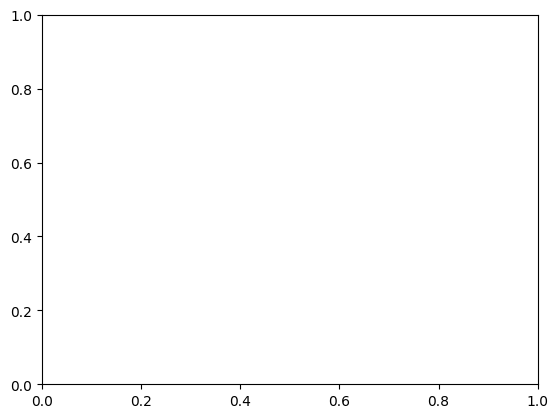

In [ ]:
from matplotlib.colors import LogNorm

artists = hep.hist2dplot(h, flow='show', norm=LogNorm())
artists.cbar.set_label("Counts")

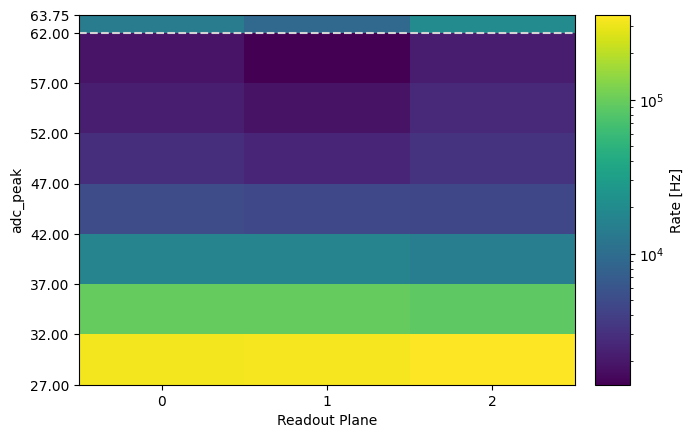

In [ ]:
sim_t = tpp.simulated_time()

h_rate_crp = h/sim_t/112

artists = hep.hist2dplot(h_rate_crp, flow='show', norm=LogNorm())
artists.cbar.set_label("Rate [Hz]")

In [ ]:
h_rate_crt_col_all.values()

array([884.41209821, 245.78015625,  84.07524554,  58.03488839,
        49.76446429,  44.04745536,  39.3390625 ])

[      0. 1556302.  455721.   81777.   22225.   11759.    8857.    6708.
   42548.]

+-----------------------------------------------------------+
[27, 32) 2185897 |========================================================== |
[32, 37) 629595  |=================                                          |
[37, 42) 173874  |=====                                                      |
[42, 47) 92097   |==                                                         |
[47, 52) 69872   |==                                                         |
[52, 57) 58113   |==                                                         |
[57, 62) 49256   |=                                                          |
                 +-----------------------------------------------------------+

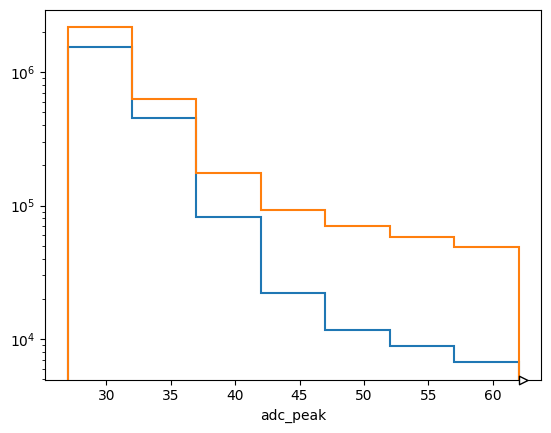

In [ ]:
from tpvalidator.analysis.histograms import cumsum_hist

v=1
h_coll = h[v,:]


fig, ax = plt.subplots()
print(h_coll.values(flow=True))
hep.histplot(h_coll, ax=ax)

h_coll_cum = cumsum_hist(h_coll, direction='right', flow=True)
hep.histplot(h_coll_cum, ax=ax)

ax.set_yscale('log')

print(h_coll_cum)



26

+-----------------------------------------------------------------+
-1 0       |                                                                 |
 0 2199819 |============================================================     |
 1 2185897 |============================================================     |
 2 2330686 |================================================================ |
 3 0       |                                                                 |
           +-----------------------------------------------------------------+

30

+------------------------------------------------------------------+
-1 0      |                                                                  |
 0 881677 |================================================================= |
 1 855305 |===============================================================   |
 2 878064 |================================================================= |
 3 0      |                                                                  |
          +------------------------------------------------------------------+

34

...

+------------------------------------------------------------------+
-1 0      |                                                                  |
 0 157645 |=========================================================         |
 1 125304 |=============================================                     |
 2 181359 |================================================================= |
 3 0      |                                                                  |
          +------------------------------------------------------------------+

42

+------------------------------------------------------------------+
-1 0      |                                                                  |
 0 117564 |====================================================              |
 1 85635  |======================================                            |
 2 147275 |================================================================= |
 3 0      |                                                                  |
          +------------------------------------------------------------------+

46

+------------------------------------------------------------------+
-1 0      |                                                                  |
 0 100582 |==================================================                |
 1 69872  |===================================                               |
 2 131144 |================================================================= |
 3 0      |                                                                  |
          +------------------------------------------------------------------+

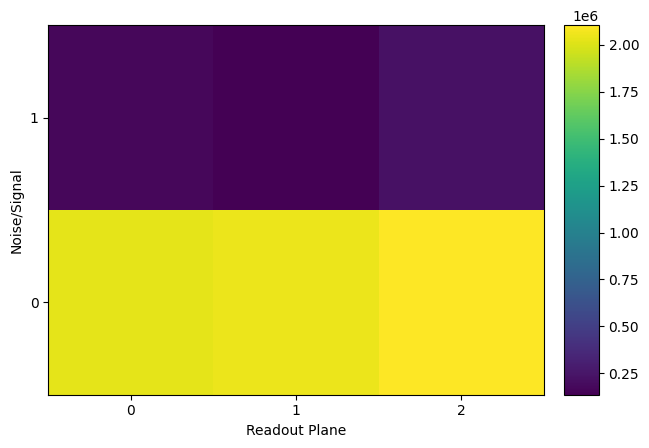

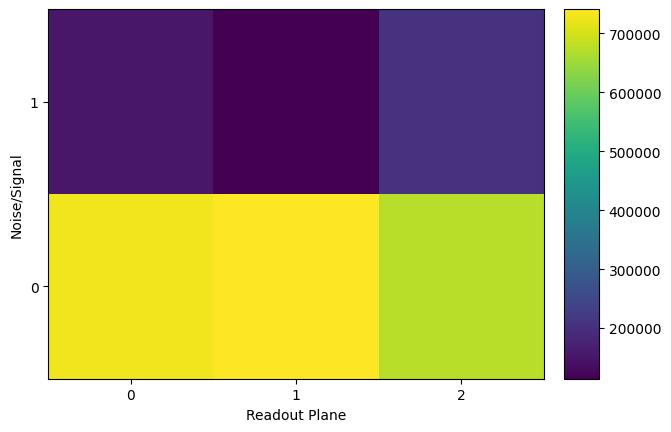

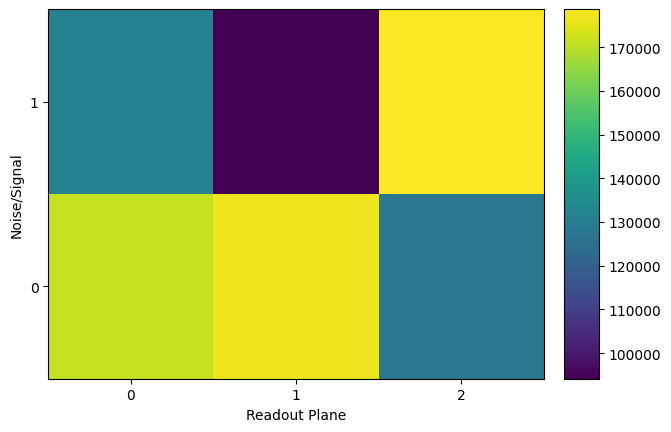

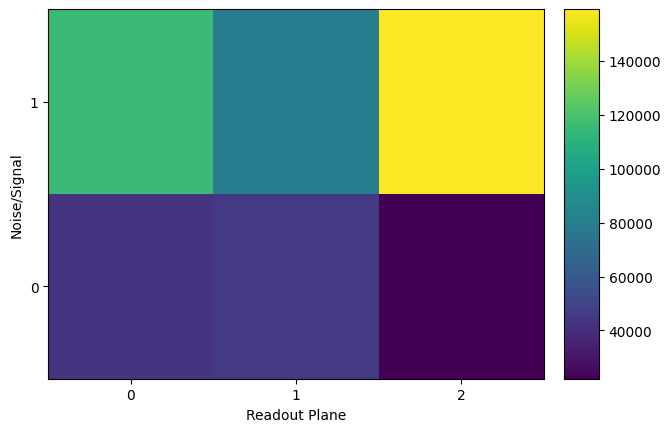

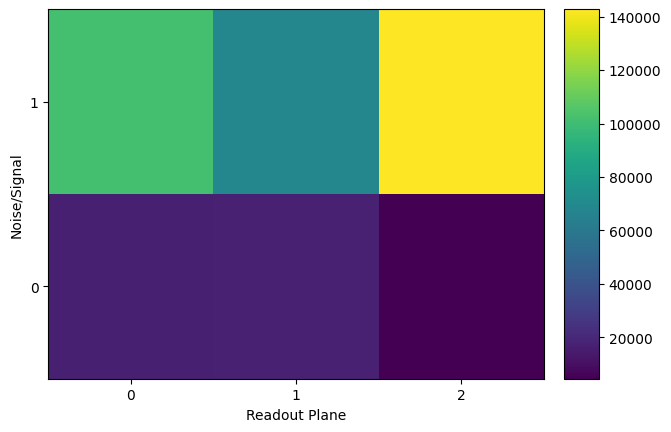

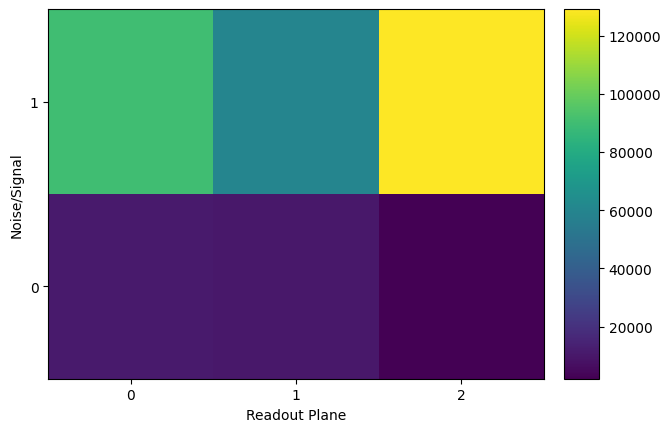

In [ ]:






hists = {}
for adc_thres in range(26, 50, 4):
    _df_cut=_df.query(f'adc_peak > {adc_thres}')

    h = hist.Hist(rop_axis, bt_sig_axis)

    h.fill(readout_plane_id=_df_cut['readout_plane_id'], bt_is_signal=_df_cut['bt_is_signal'])

    # display(h)
    hists[adc_thres] = h

for n,h in hists.items():
    fig, ax = plt.subplots()
    hep.hist2dplot(h, ax=ax)

for n,h in hists.items():
    print(n)
    print(h[:, sum])



In [ ]:
tpsel.sig_by_view[0]

event    run  subrun  version  flag  detid  channel  \
entry subentry                                                        
0     0             1  99001       0        2     0      3    95922   
      1             1  99001       0        2     0      3    95923   
      3             1  99001       0        2     0      3    95944   
      9             1  99001       0        2     0      3    95949   
      15            1  99001       0        2     0      3    95954   
...               ...    ...     ...      ...   ...    ...      ...   
9     668022        5  99001       1        2     0      3      257   
      668023        5  99001       1        2     0      3      258   
      668027        5  99001       1        2     0      3      264   
      668028        5  99001       1        2     0      3      264   
      668029        5  99001       1        2     0      3      267   

                samples_over_threshold  time_start  samples_to_peak  ...  \
entry subentry                                                       ...   
0     0                              2       50144                1  ...   
      1                              6       50016                3  ...   
      3                              6      162464                3  ...   
      9                              2      157408                0  ...   
      15                             4       36064                3  ...   
...                                ...         ...              ...  ...   
9     668022                         6      250336                2  ...   
      668023                         6      250336                2  ...   
      668027                         4       39872                2  ...   
      668028                         6      202432                3  ...   
      668029                         1      236480                0  ...   

                bt_primary_x  bt_primary_y  bt_primary_z  bt_truth_block_id  \
entry subentry                                                                
0     0           198.401642    513.960205   1969.147583                  8   
      1           198.402817    513.966858   1969.153076                  8   
      3            35.387203    512.494141   2003.964478                  8   
      9           313.666901    540.348145   1963.247925                 10   
      15         -177.105255    545.124084   1962.454102                  8   
...                      ...           ...           ...                ...   
9     668022      128.925674   -526.858521    139.013382                  8   
      668023      128.925125   -526.856445    139.012863                  8   
      668027      321.325348   -515.180786    128.937729                 10   
      668028      324.570862   -513.353638    125.073624                 10   
      668029      261.730408   -523.645203    147.610962                 10   

                          bt_generator_name  event_uid  time_peak  \
entry subentry                                                      
0     0                        Ar39GenInLAr  216752193      50176   
      1                        Ar39GenInLAr  216752193      50112   
      3                        Ar39GenInLAr  216752193     162560   
      9         CavernwallGammasAtLAr1x8x14  216752193     157408   
      15                       Ar39GenInLAr  216752193      36160   
...                                     ...        ...        ...   
9     668022                   Ar39GenInLAr  216752297     250400   
      668023                   Ar39GenInLAr  216752297     250400   
      668027    CavernwallGammasAtLAr1x8x14  216752297      39936   
      668028    CavernwallGammasAtLAr1x8x14  216752297     202528   
      668029    CavernwallGammasAtLAr1x8x14  216752297     236480   

                sample_start  sample_peak  bt_is_signal  
entry subentry                                           
0     0                 1567         1568             1  
   

In [ ]:
tpp._make_groups(tpp.df, 'signal_noise')

{0:                 event    run  subrun  version  flag  detid  channel  \
 entry subentry                                                        
 0     2             1  99001       0        2     0      3    95941   
       4             1  99001       0        2     0      3    95947   
       5             1  99001       0        2     0      3    95947   
       6             1  99001       0        2     0      3    95948   
       7             1  99001       0        2     0      3    95948   
 ...               ...    ...     ...      ...   ...    ...      ...   
 9     672146        5  99001       1        2     0      3      863   
       672147        5  99001       1        2     0      3      863   
       672148        5  99001       1        2     0      3      863   
       672149        5  99001       1        2     0      3      863   
       672151        5  99001       1        2     0      3      863   
 
                 samples_over_threshold  time_start  sample

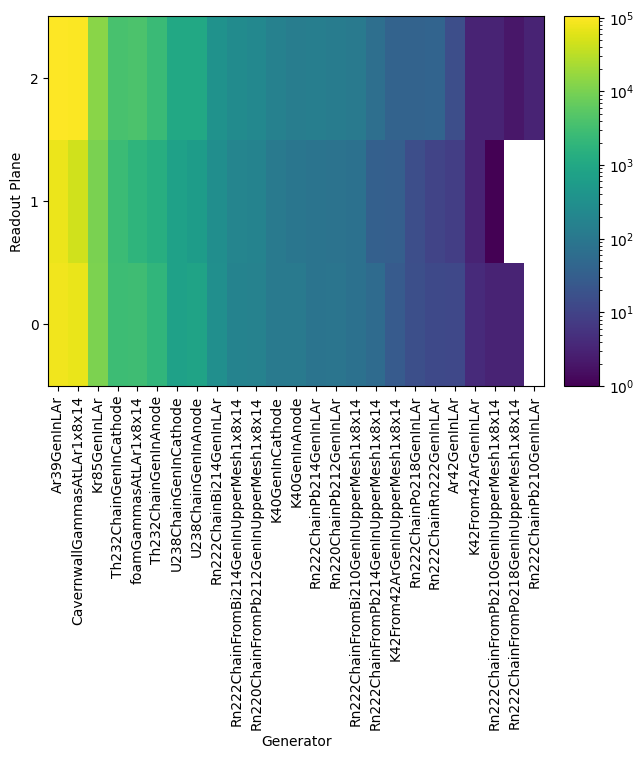

In [ ]:

from matplotlib.colors import LogNorm

fig, ax = plt.subplots()
h = tpp.make_generator_counts_hist('bt_is_signal == 1')
norm = LogNorm(vmin=1, vmax=h.values().max())

hep.hist2dplot(h, ax=ax,  norm=norm)
ax.tick_params(axis='x', rotation=90)


In [ ]:
display(h[sum, :])

IndexError: Wrong number of indices for histogram

In [ ]:
fig = tpp.plot_generator_activity(cut='adc_peak>45', norm='rate')

AttributeError: 'TrgPrimitivesPlotter' object has no attribute 'plot_generator_activity'

In [ ]:
print(tpp.make_generator_rates_table( "adc_peak >45 & readout_plane_id==0"))
print(tpp.make_generator_rates_table( "adc_peak >45 & readout_plane_id==1"))
print(tpp.make_generator_rates_table( "adc_peak >45 & readout_plane_id==2"))

                Backgrounds generators by activity                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┓
┃ generator name                          ┃ entries ┃ rate [Hz]  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━┩
│ CavernwallGammasAtLAr1x8x14             │ 44010   │ 1035529.41 │
│ Ar39GenInLAr                            │ 36911   │ 868494.12  │
│ ElecNoise                               │ 11457   │ 269576.47  │
│ Kr85GenInLAr                            │ 5564    │ 130917.65  │
│ foamGammasAtLAr1x8x14                   │ 1817    │ 42752.94   │
│ Th232ChainGenInAnode                    │ 1395    │ 32823.53   │
│ Th232ChainGenInCathode                  │ 1278    │ 30070.59   │
│ U238ChainGenInAnode                     │ 582     │ 13694.12   │
│ U238ChainGenInCathode                   │ 307     │ 7223.53    │
│ Rn222ChainBi214GenInLAr                 │ 164     │ 3858.82    │
│ K40GenInAnode                           │ 97      │ 2282.35    │
│ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 95      │ 2235.29    │
│ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 94      │ 2211.76    │
│ K40GenInCathode                         │ 56      │ 1317.65    │
│ Rn220ChainPb212GenInLAr                 │ 56      │ 1317.65    │
│ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 30      │ 705.88     │
│ Rn222ChainPb214GenInLAr                 │ 29      │ 682.35     │
│ K42From42ArGenInUpperMesh1x8x14         │ 21      │ 494.12     │
│ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 11      │ 258.82     │
│ Ar42GenInLAr                            │ 7       │ 164.71     │
│ K42From42ArGenInLAr                     │ 3       │ 70.59      │
│ Rn222ChainPo218GenInLAr                 │ 1       │ 23.53      │
└─────────────────────────────────────────┴─────────┴────────────┘

               Backgrounds generators by activity                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┓
┃ generator name                          ┃ entries ┃ rate [Hz] ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━┩
│ CavernwallGammasAtLAr1x8x14             │ 32375   │ 761764.71 │
│ Ar39GenInLAr                            │ 20838   │ 490305.88 │
│ ElecNoise                               │ 11196   │ 263435.29 │
│ Kr85GenInLAr                            │ 3631    │ 85435.29  │
│ foamGammasAtLAr1x8x14                   │ 1367    │ 32164.71  │
│ Th232ChainGenInCathode                  │ 1141    │ 26847.06  │
│ Th232ChainGenInAnode                    │ 1128    │ 26541.18  │
│ U238ChainGenInAnode                     │ 461     │ 10847.06  │
│ U238ChainGenInCathode                   │ 241     │ 5670.59   │
│ Rn222ChainBi214GenInLAr                 │ 134     │ 3152.94   │
│ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 85      │ 2000.00   │
│ K40GenInAnode                           │ 83      │ 1952.94   │
│ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 81      │ 1905.88   │
│ Rn220ChainPb212GenInLAr                 │ 46      │ 1082.35   │
│ K40GenInCathode                         │ 39      │ 917.65    │
│ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 25      │ 588.24    │
│ Rn222ChainPb214GenInLAr                 │ 20      │ 470.59    │
│ K42From42ArGenInUpperMesh1x8x14         │ 19      │ 447.06    │
│ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 11      │ 258.82    │
│ Ar42GenInLAr                            │ 2       │ 47.06     │
│ K42From42ArGenInLAr                     │ 2       │ 47.06     │
│ Rn222ChainRn222GenInLAr                 │ 2       │ 47.06     │
└─────────────────────────────────────────┴─────────┴───────────┘

                Backgrounds generators by activity                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┓
┃ generator name                          ┃ entries ┃ rate [Hz]  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━┩
│ CavernwallGammasAtLAr1x8x14             │ 60735   │ 1429058.82 │
│ Ar39GenInLAr                            │ 55715   │ 1310941.18 │
│ Kr85GenInLAr                            │ 7752    │ 182400.00  │
│ foamGammasAtLAr1x8x14                   │ 2448    │ 57600.00   │
│ ElecNoise                               │ 2417    │ 56870.59   │
│ Th232ChainGenInCathode                  │ 1822    │ 42870.59   │
│ Th232ChainGenInAnode                    │ 1773    │ 41717.65   │
│ U238ChainGenInAnode                     │ 726     │ 17082.35   │
│ U238ChainGenInCathode                   │ 429     │ 10094.12   │
│ Rn222ChainBi214GenInLAr                 │ 203     │ 4776.47    │
│ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 131     │ 3082.35    │
│ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 120     │ 2823.53    │
│ K40GenInAnode                           │ 112     │ 2635.29    │
│ K40GenInCathode                         │ 83      │ 1952.94    │
│ Rn220ChainPb212GenInLAr                 │ 72      │ 1694.12    │
│ Rn222ChainPb214GenInLAr                 │ 59      │ 1388.24    │
│ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 49      │ 1152.94    │
│ K42From42ArGenInUpperMesh1x8x14         │ 30      │ 705.88     │
│ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 21      │ 494.12     │
│ Ar42GenInLAr                            │ 7       │ 164.71     │
│ Rn222ChainRn222GenInLAr                 │ 3       │ 70.59      │
│ K42From42ArGenInLAr                     │ 2       │ 47.06      │
│ Rn222ChainPo218GenInLAr                 │ 2       │ 47.06      │
└─────────────────────────────────────────┴─────────┴────────────┘

In [ ]:
coll_tps = ws.tps.query('readout_view == 2 & sample_start >100 & sample_start < 8100 & bt_is_signal == 1 ')
coll_tps.extra_info.update({'readout_window': 8000})


NameError: name 'ws' is not defined

In [ ]:
tps_by_gen = sorted([(n,df) for n,df in coll_tps.groupby('bt_generator_name')], reverse=True, key=lambda x: len(x[1]))


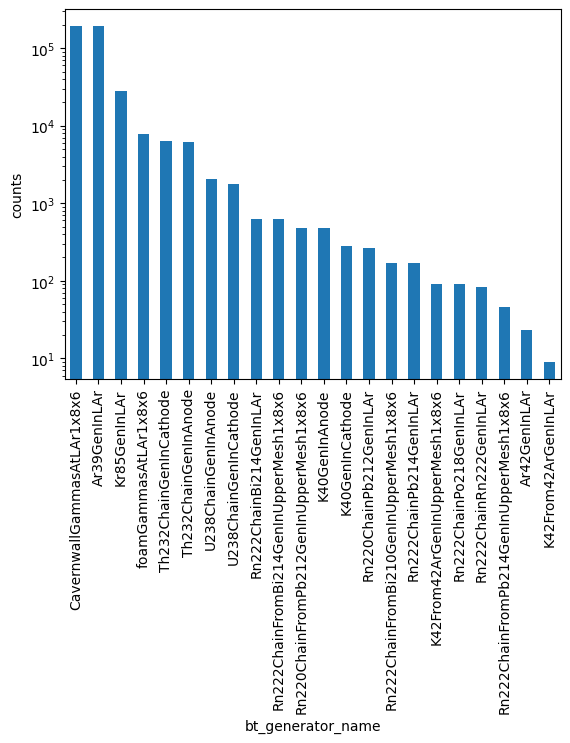

In [ ]:
counts = coll_tps.bt_generator_name.value_counts()
ax = counts.plot.bar()
ax.set_ylabel('counts')
ax.set_yscale('log')